In [2]:
import pandas as pd


In [3]:
my_data = pd.read_csv("../data/my_export.csv")
my_data.head()

,Book Id,Title,Author,Author l-f,Additional Authors,ISBN,ISBN13,My Rating,Publisher,Binding,...,Date Read,Date Added,Bookshelves,Bookshelves with positions,Exclusive Shelf,My Review,Spoiler,Private Notes,Read Count,Owned Copies
0,235426574,Svědectví o životě v KLDR 2,Nina Špitálníková,"Špitálníková, Nina","Zuzana Slavíková, Filip Kaňkovský, Eva Podzimk...","=""""","=""""",5.0,Radioservis,Audiobook,...,NaN,2026/09/08,NaN,NaN,read,NaN,NaN,NaN,2,0
1,62050269,"A Brief History of Intelligence: Evolution, AI...",Max Solomon Bennett,"Bennett, Max Solomon",NaN,"=""""","=""""",0.0,Mariner Books,Hardcover,...,NaN,2025/11/05,currently-reading,currently-reading (#4),currently-reading,NaN,NaN,NaN,1,0
2,39101777,Surrounded by Idiots,Thomas Erikson,"Erikson, Thomas",NaN,"=""125023400X""","=""9781250234001""",3.0,Macmillan Audio,Audiobook,...,2026/07/25,2026/06/21,NaN,NaN,read,NaN,NaN,NaN,1,0
3,14096,"Wherever You Go, There You Are: Mindfulness Me...",Jon Kabat-Zinn,"Kabat-Zinn, Jon",NaN,"=""1401307787""","=""9781401307783""",0.0,Balance,Paperback,...,NaN,2026/07/01,to-read,to-read (#194),to-read,NaN,NaN,NaN,0,0
4,15805413,"The Dalai Lama's Cat (The Dalai Lama's Cat, #1)",David Michie,"Michie, David",NaN,"=""1401940587""","=""9781401940584""",0.0,Hay House Visions,Paperback,...,NaN,2026/06/29,to-read,to-read (#193),to-read,NaN,NaN,NaN,0,0


In [8]:
my_data.columns

Index(['Book Id', 'Title', 'Author', 'Author l-f', 'Additional Authors',
       'ISBN', 'ISBN13', 'My Rating', 'Publisher', 'Binding',
       'Number of Pages', 'Year Published', 'Original Publication Year',
       'Date Read', 'Date Added', 'Bookshelves', 'Bookshelves with positions',
       'Exclusive Shelf', 'My Review', 'Spoiler', 'Private Notes',
       'Read Count', 'Owned Copies'],
      dtype='str')

In [9]:
my_data.isna().sum()

Book Id                         0
Title                           0
Author                          0
Author l-f                      0
Additional Authors            233
ISBN                            0
ISBN13                          0
My Rating                       0
Publisher                       4
Binding                         0
Number of Pages                 3
Year Published                  1
Original Publication Year      20
Date Read                     256
Date Added                      0
Bookshelves                   104
Bookshelves with positions    104
Exclusive Shelf                 0
My Review                     303
Spoiler                       303
Private Notes                 303
Read Count                      0
Owned Copies                    0
dtype: int64

In [13]:
my_data['My Rating'].describe()

count    303.000000
mean       1.026403
std        1.883871
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        5.000000
Name: My Rating, dtype: float64

## Exploratory plots

In [15]:
import ast
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.append("..")
from src.plotting import use_style, hbar, BLUE, ORANGE, AQUA, INK_SECONDARY

use_style()

read = my_data[my_data["Exclusive Shelf"] == "read"]
rated = my_data[my_data["My Rating"] > 0]   # Goodreads stores "not rated" as 0

### Shelves and ratings

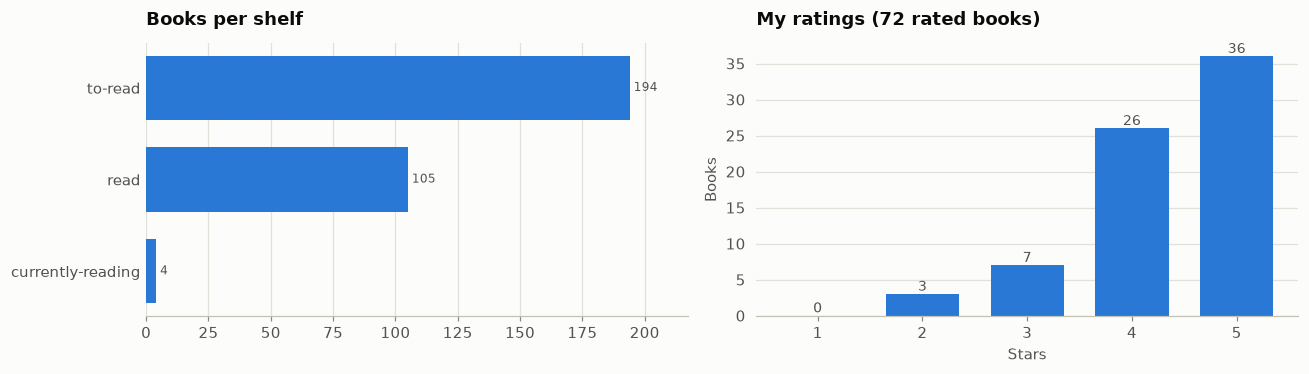

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.5), gridspec_kw={"width_ratios": [1, 1]})

hbar(ax1, my_data["Exclusive Shelf"].value_counts(), "Books per shelf")

ratings = rated["My Rating"].astype(int).value_counts().reindex(range(1, 6), fill_value=0)
ax2.bar(ratings.index, ratings.values, color=BLUE, width=0.7)
for x, value in zip(ratings.index, ratings.values):
    ax2.text(x, value, f"{value}", ha="center", va="bottom", fontsize=9, color=INK_SECONDARY)
ax2.set(title=f"My ratings ({len(rated)} rated books)", xlabel="Stars", ylabel="Books", xticks=range(1, 6))
plt.tight_layout()
plt.show()

### Reading over time

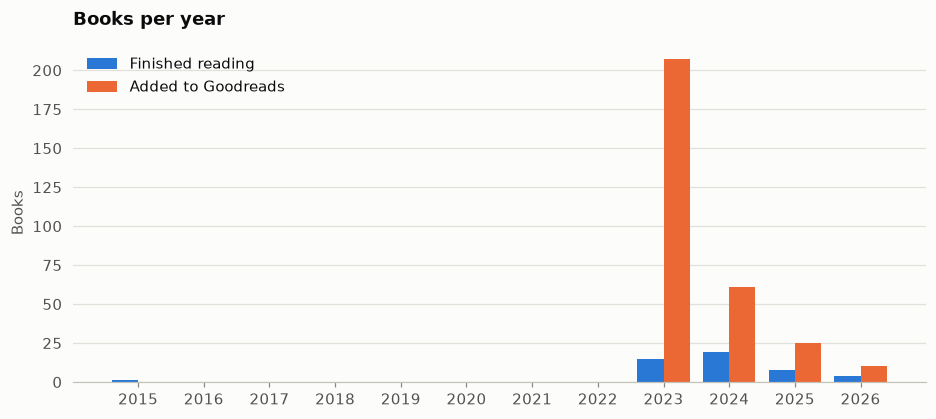

Read books without a 'Date Read': 58


In [17]:
read_year = pd.to_datetime(read["Date Read"], errors="coerce").dt.year.dropna().astype(int)
added_year = pd.to_datetime(my_data["Date Added"], errors="coerce").dt.year.dropna().astype(int)

years = range(min(read_year.min(), added_year.min()), max(read_year.max(), added_year.max()) + 1)
read_counts = read_year.value_counts().reindex(years, fill_value=0)
added_counts = added_year.value_counts().reindex(years, fill_value=0)

x = np.arange(len(years))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - 0.2, read_counts.values, width=0.4, color=BLUE, label="Finished reading")
ax.bar(x + 0.2, added_counts.values, width=0.4, color=ORANGE, label="Added to Goodreads")
ax.set_xticks(x, [str(y) for y in years])
ax.set(title="Books per year", ylabel="Books")
ax.legend(loc="upper left")
plt.show()

print(f"Read books without a 'Date Read': {read['Date Read'].isna().sum()}")

### Publication year
The *Best Books Ever* dataset was scraped in 2020, so anything published later can't be matched against `books.csv`.

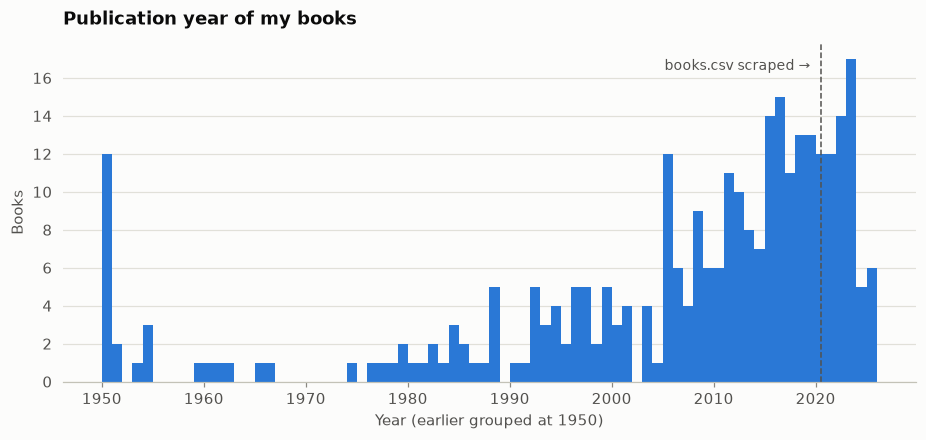

Published after 2020: 54 of 303


In [18]:
pub_year = my_data["Original Publication Year"].fillna(my_data["Year Published"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pub_year.clip(lower=1950), bins=np.arange(1950, pub_year.max() + 2, 1), color=BLUE)
ax.axvline(2020.5, color=INK_SECONDARY, linestyle="--", linewidth=1)
ax.text(2019.5, ax.get_ylim()[1] * 0.92, "books.csv scraped →", ha="right", color=INK_SECONDARY, fontsize=9)
ax.set(title="Publication year of my books", xlabel="Year (earlier grouped at 1950)", ylabel="Books")
plt.show()

print(f"Published after 2020: {(pub_year > 2020).sum()} of {len(pub_year)}")

### Pages and authors

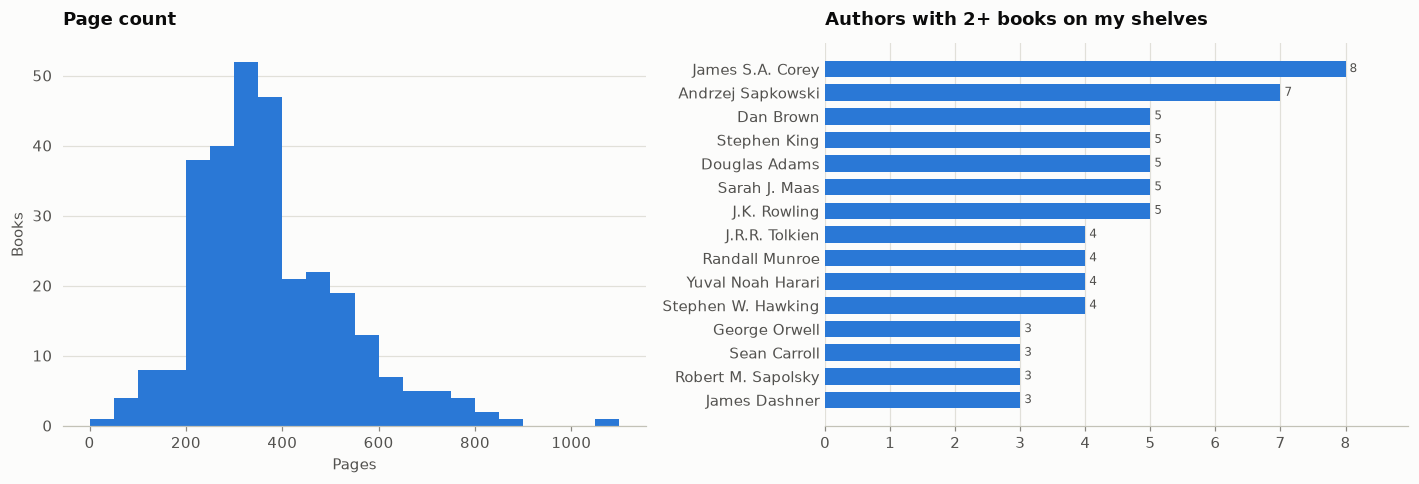

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

pages = my_data["Number of Pages"]
ax1.hist(pages[pages > 0], bins=np.arange(0, pages.max() + 50, 50), color=BLUE)
ax1.set(title="Page count", xlabel="Pages", ylabel="Books")

authors = my_data["Author"].str.replace(r"\s+", " ", regex=True).str.strip().value_counts()  # export has "Dan    Brown"
hbar(ax2, authors[authors >= 2].head(15), "Authors with 2+ books on my shelves")
plt.tight_layout()
plt.show()

### Enriched data
Needs `data/my_books_enriched.csv`, which `python src/enrich.py` creates.

In [21]:
enriched_path = Path("../data/my_books_enriched.csv")
enriched = pd.read_csv(enriched_path) if enriched_path.exists() else None

if enriched is None:
    print("Run `python src/enrich.py` first.")
else:
    source = enriched["description_source"].fillna("missing")
    by_shelf = pd.crosstab(source, enriched["shelf"])
    by_shelf = by_shelf.loc[by_shelf.sum(axis=1).sort_values().index]

    fig, ax = plt.subplots(figsize=(9, 3.8))
    left = np.zeros(len(by_shelf))
    for shelf, color in zip(["read", "currently-reading", "to-read"], [BLUE, ORANGE, AQUA]):
        if shelf in by_shelf:
            ax.barh(by_shelf.index, by_shelf[shelf], left=left, color=color, height=0.7, label=shelf)
            left += by_shelf[shelf].values
    for y, total in enumerate(left):
        ax.text(total, y, f" {total:.0f}", va="center", fontsize=8, color=INK_SECONDARY)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", visible=True)
    ax.tick_params(axis="y", length=0)
    ax.margins(x=0.08)
    ax.set(title="Where each description came from", xlabel="Books")
    ax.legend(loc="lower right")
    plt.show()

Run `python src/enrich.py` first.


In [22]:
if enriched is not None:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), gridspec_kw={"width_ratios": [1, 1.3]})

    desc_len = enriched["description"].str.len()
    ax1.hist(desc_len.dropna().clip(upper=4000), bins=40, color=BLUE)
    ax1.axvline(1000, color=INK_SECONDARY, linestyle="--", linewidth=1)
    ax1.set(title="Description length", xlabel="Characters (clipped at 4,000)", ylabel="Books")

    # Genre tags come from different sources (Goodreads, Google Books, Open Library), so they aren't uniform yet
    my_genres = enriched["genres"].dropna().apply(ast.literal_eval).explode().dropna()
    hbar(ax2, my_genres.value_counts().head(20), "Top 20 genre tags in my books")
    plt.tight_layout()
    plt.show()